In [14]:
import pandas as pd
import numpy as np
from utils.plot_functions import plot_yearly_bar_chart

In [24]:
DATASET_PATH = "data/openalex_ai_healthcare_publications_1980_2026_filtered_2.csv"

In [25]:
publications_df = pd.read_csv(DATASET_PATH)

### **1. Publication Growth of AI in Medicine Over the Last 46 Years**

The first step of this analysis is to examine how the volume of scientific publications related to **Artificial Intelligence in Medicine** has evolved over time. For this purpose, I use the previously built dataset and count number of papers by year.

This visualization helps identify growth patterns, periods of slow development, and moments where the field started accelerating. In particular, it allows us to observe whether the rise of modern machine learning and deep learning methods is reflected in the scientific literature.

In [26]:
publications_count_by_year = (
    publications_df
    .groupby("publication_year")
    .size()
    .reset_index(name="publication_count")
    .sort_values("publication_year")
)

In [27]:
years_list = publications_count_by_year["publication_year"].tolist()
counts_list = publications_count_by_year["publication_count"].tolist()

In [28]:
print(f"Number of papers published between 1980-2026: {sum(counts_list)}")

Number of papers published between 1980-2026: 853899


In [29]:
peak_index = np.argmax(counts_list)
peak_year = years_list[peak_index]
peak_year_publications = counts_list[peak_index]

In [30]:
print(f"Peak year is {peak_year} with {peak_year_publications} publications")

Peak year is 2025 with 145327 publications


#### **1.1 Linear Scale**
First, the publication trend is visualized using a standard linear scale. This view highlights the absolute increase in the number of papers and makes it easy to observe the strong growth of the field in recent years.

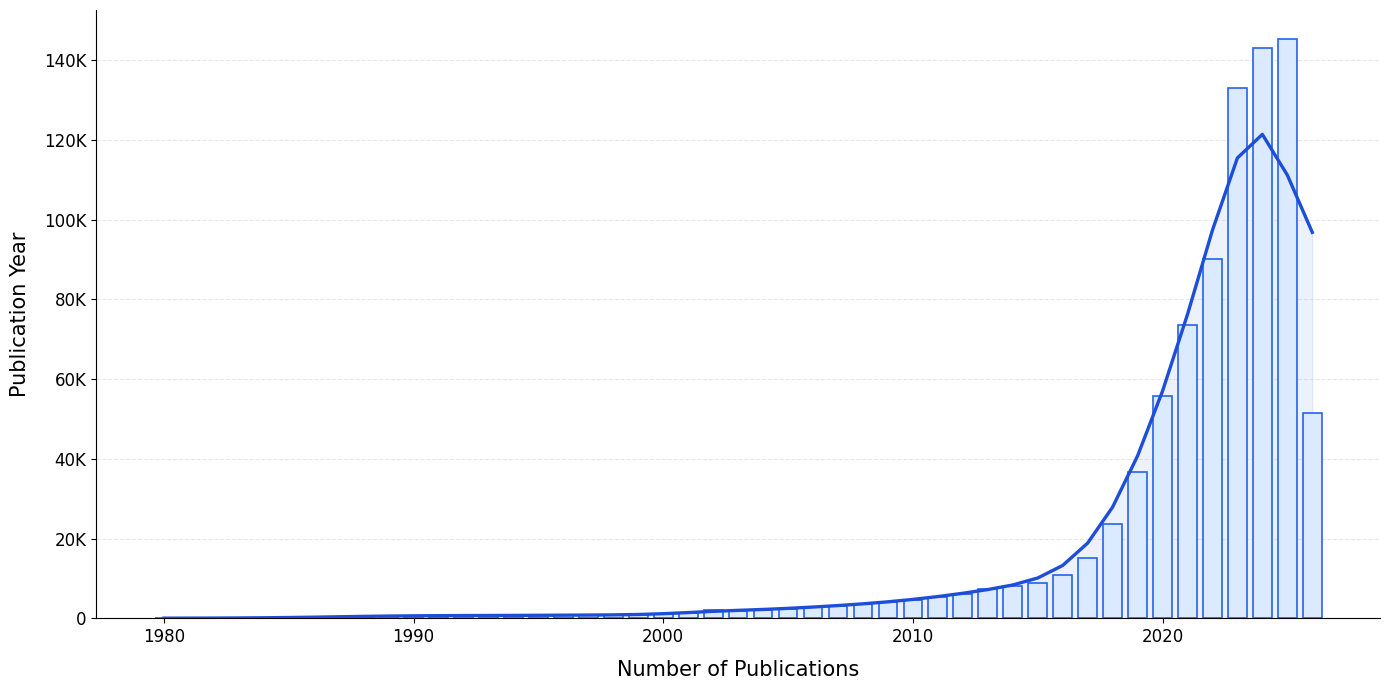

In [31]:
plot_yearly_bar_chart(
    years_list, 
    counts_list, 
    xlabel = "Number of Publications",
    ylabel = "Publication Year",
    save_file = "figures/publication_growth_ai_medicine.png"
)

#### **1.2 Logarithmic Scale**
The same trend is also shown using a logarithmic scale. This second view is useful because publication counts can grow very rapidly over time, making earlier years difficult to interpret on a normal scale. The log-scale visualization helps reveal whether the growth follows an approximately exponential pattern and makes smaller values from earlier decades more visible.

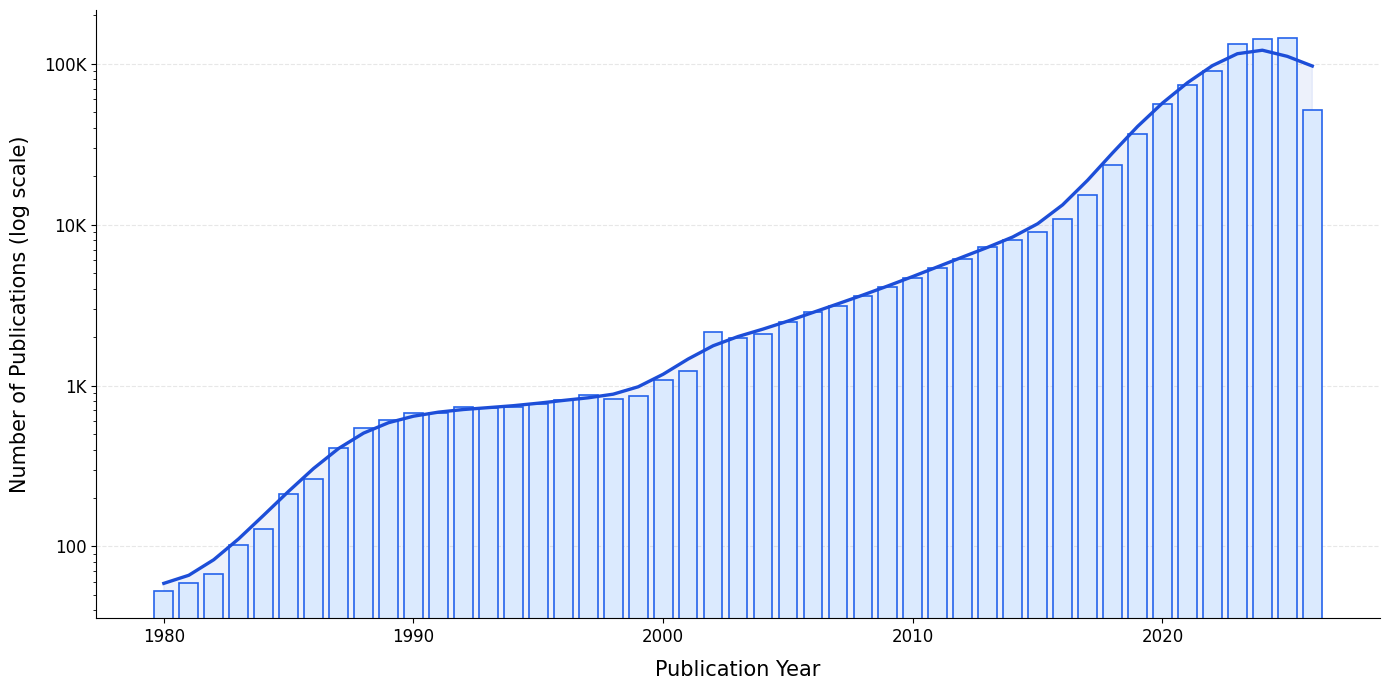

In [32]:
plot_yearly_bar_chart(
    years_list, 
    counts_list, 
    xlabel = "Publication Year",
    ylabel = "Number of Publications",
    log_scale = True,
    save_file = "figures/publication_growth_ai_medicine_log.png"
)